# Segmentación de perfiles laborales similares utilizando métodos de clustering: K-Means, DBSCAN y AgglomerativeClustering

- En el presente análisis se emplearon algoritmos de aprendizaje no supervisado, específicamente técnicas de clustering como ```K-Means```, ```DBSCAN``` y ```Agglomerative Clustering```, con el objetivo de identificar perfiles laborales similares.
- Los resultados evidencian que tanto ```K-Means``` como ```Agglomerative Clustering``` presentan una adecuada separación y consistencia en la formación de grupos. Sin embargo, ```K-Means``` obtuvo el mayor valor de ```silhouette_score```, lo que indica una mejor calidad en la cohesión y separación de los clusters, razón por la cual se profundizó en el análisis de sus características.
  
## ¿Qué variables diferencian más a los clusters o agrupamientos definidos?
- Variables más discriminativas (objetivas):
    Estas variables presentan mayor variabilidad entre clusters, por lo que tienen mayor capacidad de diferenciación.
    - Salario ```MonthlyIncome```
    - Experiencia ```TotalWorkingYears```
    - Edad ```Age```
    - Antigüedad ```YearsAtCompany```

- Variables menos discriminativas:
Estas variables varían poco entre clusters, por lo que no contribuyen significativamente a la segmentación.
    - Satisfacción ```JobSatisfaction```
    - Compromiso ```JobInvolvement```

- Se puede inferir que el modelo segmenta principalmente a los empleados en función de desarrollo profesional y trayectoria laboral, distinguiendo:
    - Empleados junior vs senior
    - Bajo vs alto ingreso
    - Menor vs mayor experiencia laboral

Es decir, el clustering está dominado por variables estructurales del empleo (edad, ingreso, experiencia), más que por variables actitudinales.

## Importación de las librerías

In [53]:
# Librerías básicas para manipulación de datos y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento de datos
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
# Construcción pipelines
from sklearn.pipeline import Pipeline
# MMétricas de evaluación para clustering
from sklearn.metrics import silhouette_score
# Algoritmos de clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
# Reducción de dimensionalidad (Análisis de Componentes Principales)
from sklearn.decomposition import PCA
# Herramientas para combinaciones de parámetros (grid manual)
from itertools import product
# Creación del dendograma para clustering jerárquico
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set(style="whitegrid", context="notebook")

## Importando el dataset

In [54]:
df = pd.read_csv("/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Explorando casos duplicados

In [55]:
df[df.duplicated(keep="first")]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


## Descripción de los datos

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [57]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [58]:
df.describe(include="object")

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


## Selección de variables para clustering mediante exclusión de variables categóricas y variables numéricas no relevantes

In [59]:
ignored_columns= df.select_dtypes(exclude=np.number).columns.tolist() + ["EmployeeNumber","EmployeeCount","NumCompaniesWorked","DailyRate","HourlyRate","MonthlyRate","PercentSalaryHike","StockOptionLevel","TrainingTimesLastYear","BusinessTravel","EnvironmentSatisfaction","RelationshipSatisfaction","WorkLifeBalance","YearsSinceLastPromotion","YearsWithCurrManager"]
df_filtered = df.drop(ignored_columns, axis=1)

## Preprocesamiento de datos mediante escalamiento Min-Max aplicado a las variables seleccionadas

In [60]:
from sklearn.preprocessing import StandardScaler

cols_num = df_filtered.select_dtypes(include=np.number).columns

preprocessor = ColumnTransformer([
    ("scaler", StandardScaler(), cols_num),
])

preprocessor.set_output(transform="pandas")
df_pre = preprocessor.fit_transform(df_filtered)
names_columns = [col.replace("scaler__","").replace("ohe__","") for col in df_pre.columns]
df_pre.columns = names_columns
df_pre.head()

,Age,DistanceFromHome,Education,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,PerformanceRating,StandardHours,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole
0,0.446350,-1.010909,-0.891688,0.379672,-0.057788,1.153254,-0.108350,-0.426230,0.0,-0.421642,-0.164613,-0.063296
1,1.322365,-0.147150,-1.868426,-1.026167,-0.057788,-0.660853,-0.291719,2.346151,0.0,-0.164511,0.488508,0.764998
2,0.008343,-0.887515,-0.891688,-1.026167,-0.961486,0.246200,-0.937654,-0.426230,0.0,-0.550208,-1.144294,-1.167687
3,-0.429664,-0.764121,1.061787,0.379672,-0.961486,0.246200,-0.763634,-0.426230,0.0,-0.421642,0.161947,0.764998
4,-1.086676,-0.887515,-1.868426,0.379672,-0.961486,-0.660853,-0.644858,-0.426230,0.0,-0.678774,-0.817734,-0.615492


In [61]:
# sns.pairplot(df_pre)
# plt.show()

## Transformación del conjunto de datos mediante PCA para obtener componentes principales

In [62]:
pca = PCA()
df_pca = pca.fit_transform(df_pre)
print(df_pca.shape)

columns = [f"comp_{i}" for i in range(1, df_pca.shape[1]+1)]
df_pca = pd.DataFrame(df_pca, columns=columns)
df_pca.head()

(1470, 12)


,comp_1,comp_2,comp_3,comp_4,comp_5,comp_6,comp_7,comp_8,comp_9,comp_10,comp_11,comp_12
0,-0.298697,0.039620,-1.127190,-0.657051,0.908505,0.588912,-0.635781,0.562308,0.277150,-0.363108,0.041552,-8.954623e-18
1,0.478349,1.949596,-0.384584,1.260914,-1.702562,0.953498,-0.645495,1.603688,0.462802,-0.627978,0.149681,3.833633e-17
2,-2.014272,-0.229425,-1.647595,-0.029257,-0.311188,-0.212594,0.025149,0.811311,-0.070552,0.161603,0.010465,2.320365e-17
3,-0.712174,0.079996,0.511320,-0.939961,0.744815,0.651834,1.359413,0.113016,0.147642,0.183663,-0.156953,-4.094831e-17
4,-2.101170,0.568161,-0.687123,-1.336655,-0.802132,0.028651,-1.129144,0.108656,-0.067153,0.320656,-0.189249,2.954026e-17


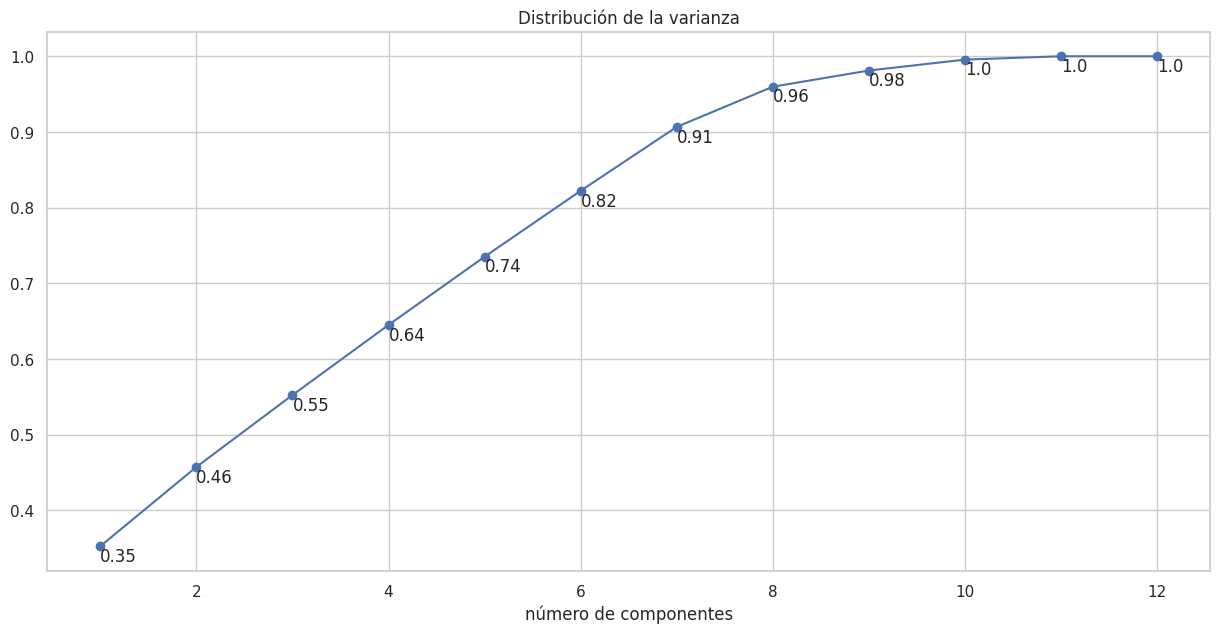

In [63]:
cums = np.cumsum(pca.explained_variance_ratio_)

fig = plt.subplots(figsize=(15,7))
plt.plot(range(1, df_pca.shape[1]+1), np.cumsum(pca.explained_variance_ratio_), "-o")
for i in range(1, df_pca.shape[1]+1):
    plt.text(i, cums[i-1]-0.02, str(cums[i-1].round(2)))
plt.xlabel("número de componentes")
plt.title("Distribución de la varianza")
plt.grid(True)
plt.show()

## Selección de componentes principales considerando un 81% de varianza explicada acumulada

In [64]:
df_pca_comp = df_pca.iloc[:,:5]

## K-Means
### Selección de n_clusters para el modelo K-Means mediante el método del codo y el índice de Silhouette

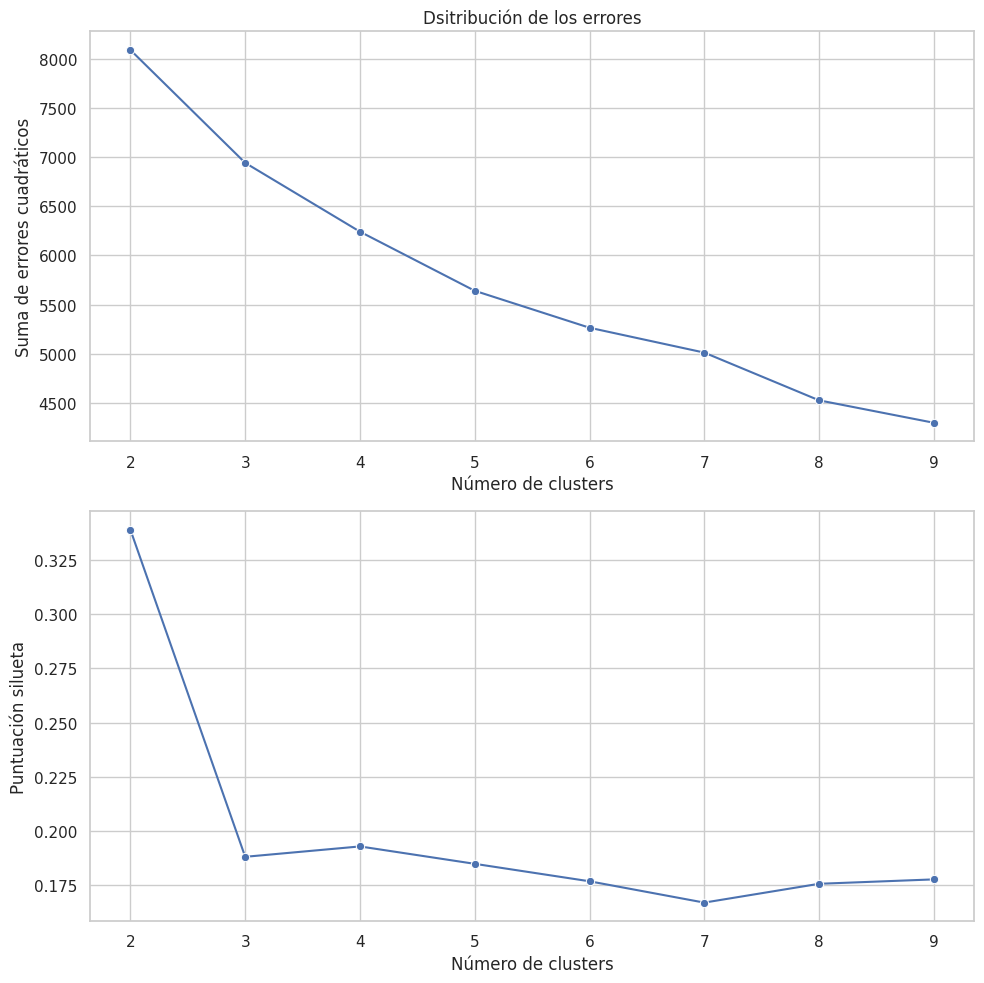

In [65]:
components = range(2, 10)
sum_squared_error = []
silhouettes_scores = []

for i in components:
    kmeans = KMeans(n_clusters=i, random_state=42)
    y_temp = kmeans.fit_predict(df_pca_comp)
    sum_squared_error.append(kmeans.inertia_)
    silhouettes_scores.append(silhouette_score(df_pca_comp, y_temp))

fig, ax = plt.subplots(2, 1, figsize=(10, 10))
ax = ax.flat
sns.lineplot(x=components, y=sum_squared_error, marker="o", ax=ax[0])
ax[0].set_xlabel("Número de clusters")
ax[0].set_ylabel("Suma de errores cuadráticos")
ax[0].set_title("Dsitribución de los errores")
ax[0].grid(True)

sns.lineplot(x=components, y=silhouettes_scores, marker="o", ax=ax[1])
ax[1].set_xlabel("Número de clusters")
ax[1].set_ylabel("Puntuación silueta")
ax[1].set_title("")
ax[1].grid(True)
plt.tight_layout()
plt.show()

### Implementación del algoritmo K-Means con hiperparámetros seleccionados

In [66]:
kmeans_main = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans_main.fit_predict(df_pca_comp)
sil_score_kmeans = np.round(silhouette_score(df_pca_comp, y_kmeans), 5)
print(f"El coeficiente de silueta en el modelo de KMeans es {sil_score_kmeans}")

El coeficiente de silueta en el modelo de KMeans es 0.1882


## DBSCAN
### Determinación del parámetro eps usando el método del codo en k-distancias

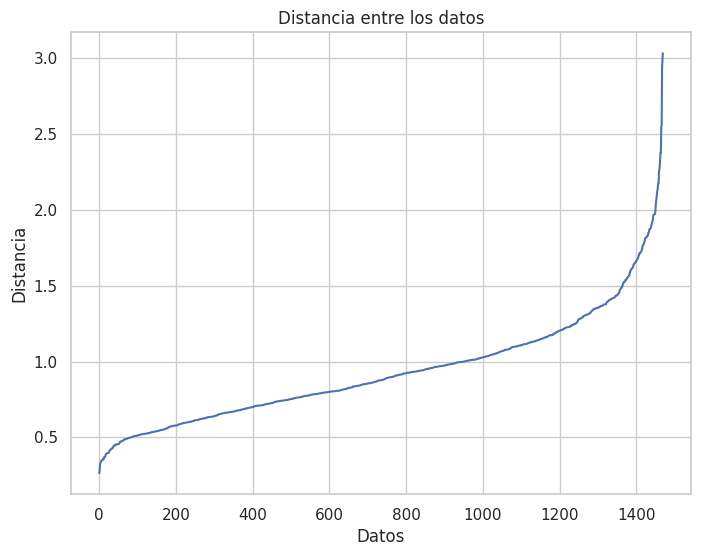

In [67]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(df_pca_comp)
distances, indices = neighbors_fit.kneighbors(df_pca_comp)

distances_ord = np.sort(distances, axis=0)
distances_ord = distances_ord[:,4]

plt.figure(figsize=(8,6))
sns.lineplot(distances_ord)
plt.xlabel("Datos")
plt.ylabel("Distancia")
plt.title("Distancia entre los datos")
plt.grid(True)
plt.show()

## Exploración de hiperparámetros (eps y min_samples) en DBSCAN con evaluación mediante Silhouette Score
$$
\text{eps: Define qué tan cerca deben estar los puntos para considerarse vecinos.}
$$
$$
\text{min\_samples: Mínimo número de puntos necesarios para formar una región densa.}
$$

In [68]:
eps = np.arange(0.1, 0.4, 0.05)
min_samples = np.arange(2, 6, 1)

eps_samples = list(product(eps, min_samples))

clusters = []
silhouette_scores = []

for eps_i, min_s in eps_samples:
    dbscan = DBSCAN(eps=eps_i, min_samples=min_s)
    labels = dbscan.fit_predict(df_pca_comp)
    # número de clusters reales (excluyendo ruido)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    clusters.append(n_clusters)
    # calcular silhouette solo si es válido
    if n_clusters >= 2:
        mask = labels != -1
        score = silhouette_score(df_pca_comp[mask],
                                 labels[mask])
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(np.nan)

dbscan_params = pd.DataFrame(eps_samples, columns=["eps", "min_samples"])
dbscan_params["clusters"] = clusters
dbscan_params["silhouette_scores"] = silhouette_scores
dbscan_params.head()

,eps,min_samples,clusters,silhouette_scores
0,0.10,2,7,0.926813
1,0.10,3,0,NaN
2,0.10,4,0,NaN
3,0.10,5,0,NaN
4,0.15,2,21,0.870570


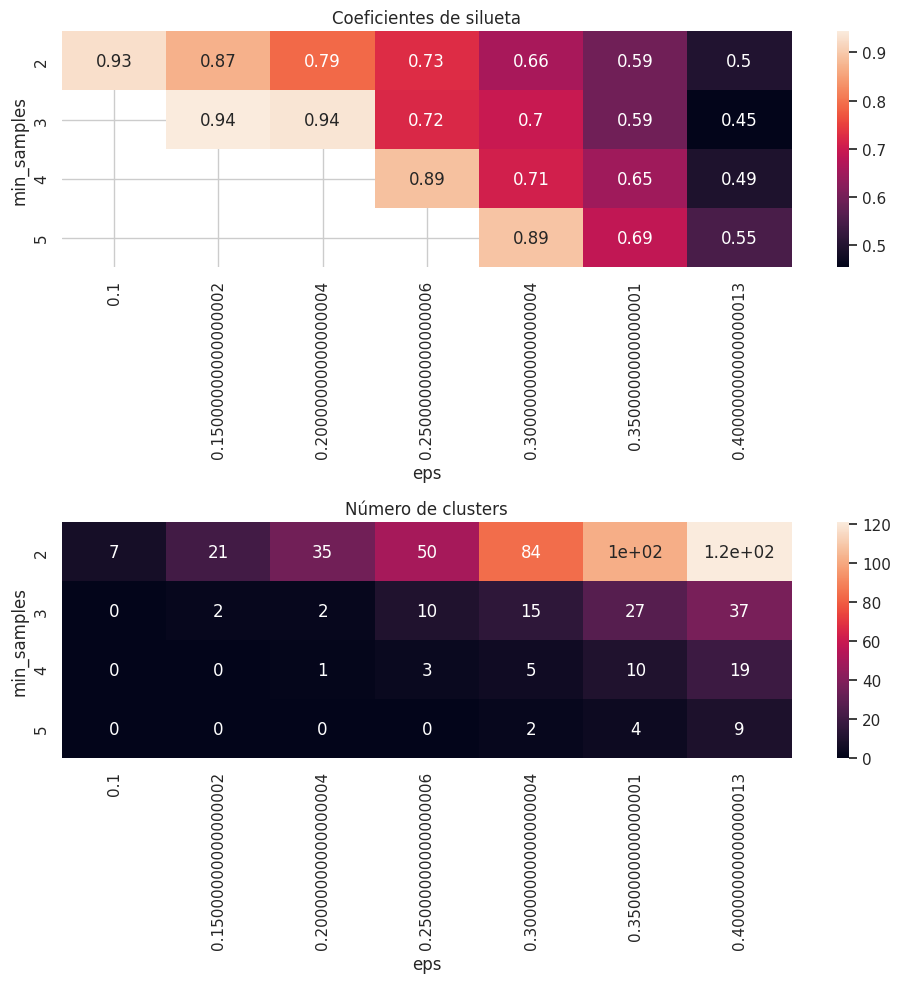

In [69]:
df_params_sil = pd.pivot_table(dbscan_params, index="min_samples",
                               columns="eps", values="silhouette_scores")
df_params_clus = pd.pivot_table(dbscan_params, index="min_samples",
                                columns="eps", values="clusters")

fig, ax = plt.subplots(2, 1, figsize=(10, 10))
ax = ax.flat
sns.heatmap(df_params_sil, annot=True, ax=ax[0])
ax[0].set_title("Coeficientes de silueta")
sns.heatmap(df_params_clus, annot=True, ax=ax[1])
ax[1].set_title("Número de clusters")
plt.tight_layout()
plt.show()

### Implementación del algoritmo DBSCAN con hiperparámetros seleccionados

In [70]:
dbscan_main = DBSCAN(eps=0.15, min_samples=3)
y_dbscan = dbscan_main.fit_predict(df_pca_comp)
sil_score_dbscan = np.round(silhouette_score(df_pca_comp, y_dbscan), 3)
print(f"El coeficiente de silueta en el modelo de DBSCAN es {sil_score_dbscan}")

El coeficiente de silueta en el modelo de DBSCAN es -0.206


## Clustering Jerárquico
### Dendrograma para la identificación de grupos de empleados

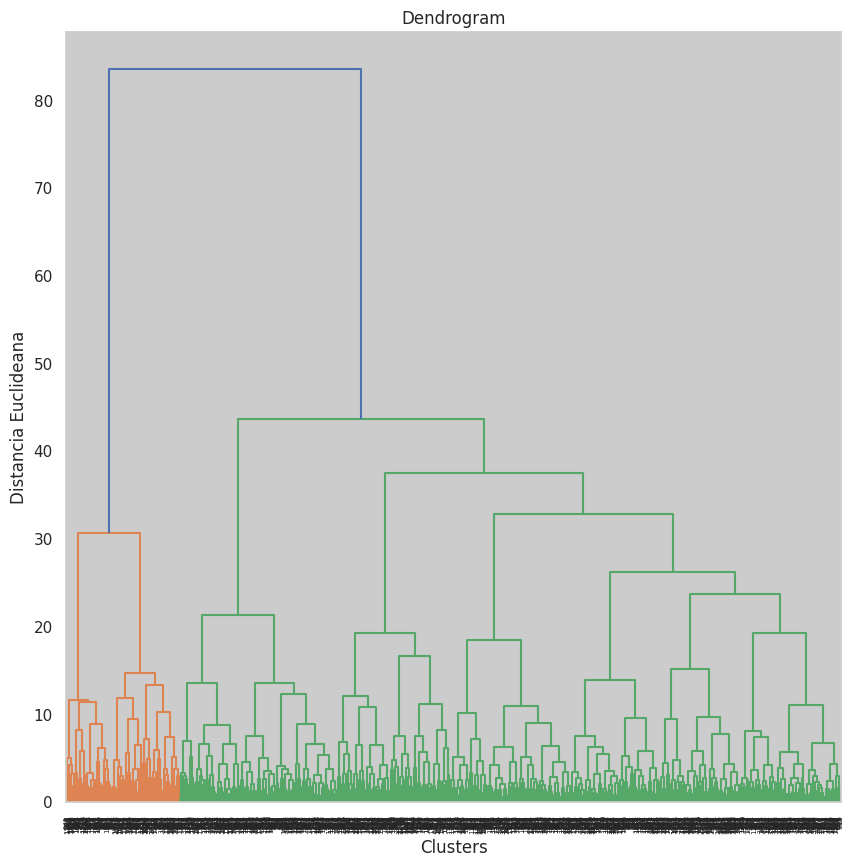

In [71]:
plt.figure(figsize=(10,10))
dendrogrma_plot = dendrogram(linkage(df_pca_comp, method="ward"))
plt.title("Dendrogram")
plt.xlabel("Clusters")
plt.ylabel("Distancia Euclideana")
plt.show()

### Implementación del algoritmo AgglomerativeClustering con hiperparámetros seleccionados

In [72]:
hc_main = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="ward")
y_hc = hc_main.fit_predict(df_pca_comp)
sil_score_hc = np.round(silhouette_score(df_pca_comp, y_hc), 4)
print(f"El coeficiente de silueta en el modelo de Agglomerative clustering es {sil_score_hc}")

El coeficiente de silueta en el modelo de Agglomerative clustering es 0.1516


## Visualización del agrupamientos de los clusters

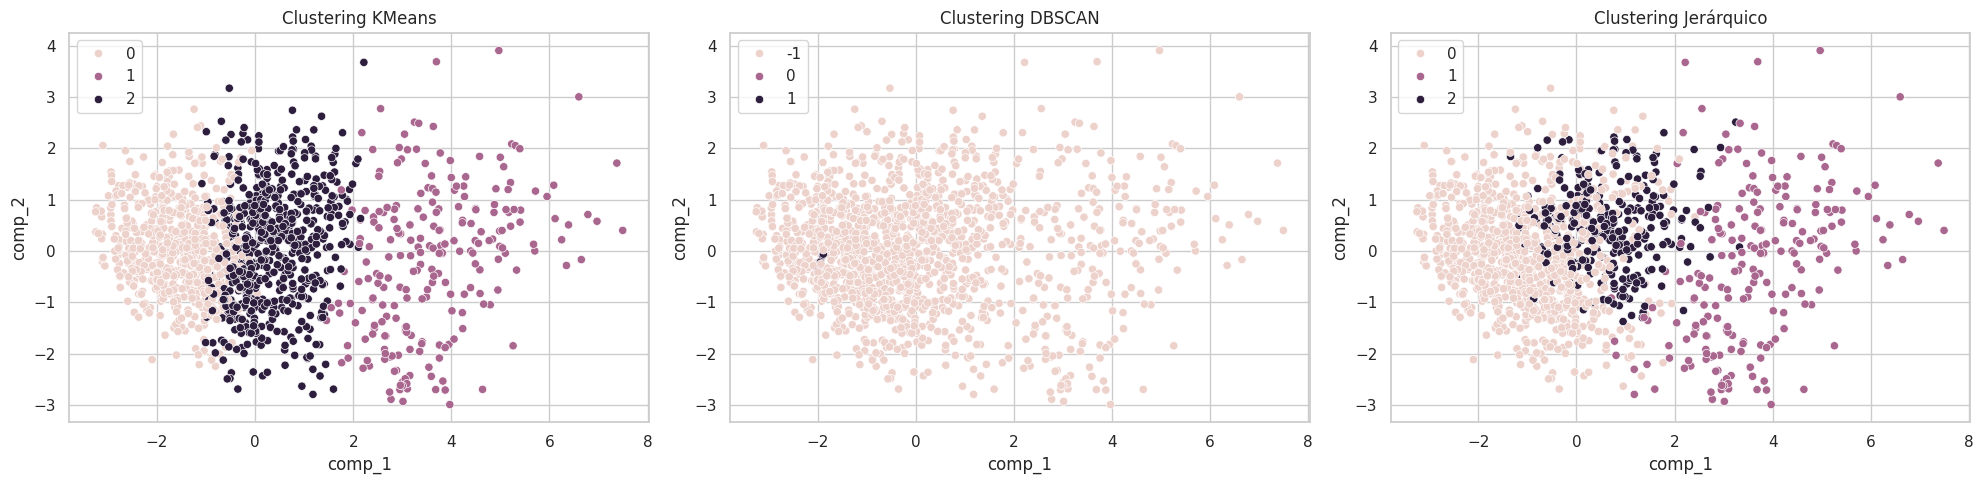

In [73]:
df_pca_comp = df_pca_comp.copy()
df_pca_comp.loc[:,"y_kmeans"] = y_kmeans
df_pca_comp.loc[:,"y_dbscan"] = y_dbscan
df_pca_comp.loc[:,"y_hc"] = y_hc

fig, ax = plt.subplots(1, 3, figsize=(20, 5))
ax = ax.flat
ax[0].set_title("Clustering KMeans")
sns.scatterplot(data=df_pca_comp, x="comp_1", y="comp_2", hue="y_kmeans", ax=ax[0])
ax[0].legend()
ax[1].set_title("Clustering DBSCAN")
sns.scatterplot(data=df_pca_comp, x="comp_1", y="comp_2", hue="y_dbscan", ax=ax[1])
ax[1].legend()
ax[2].set_title("Clustering Jerárquico")
sns.scatterplot(data=df_pca_comp, x="comp_1", y="comp_2", hue="y_hc", ax=ax[2])
ax[2].legend()
plt.tight_layout()
plt.show()

### Interpretación:
- El gráfico muestra la presencia de tres clusters principales en los datos. El algoritmo ```K-Means``` evidencia una mejor separación y consistencia entre grupos, seguido del ```clustering jerárquico```, que reproduce una estructura similar pero con mayor superposición. Por otro lado, ```DBSCAN``` no logra identificar clusters de manera significativa, lo que se infiere que los datos no presentan una distribución basada en densidad característica principal de DBSCAN.

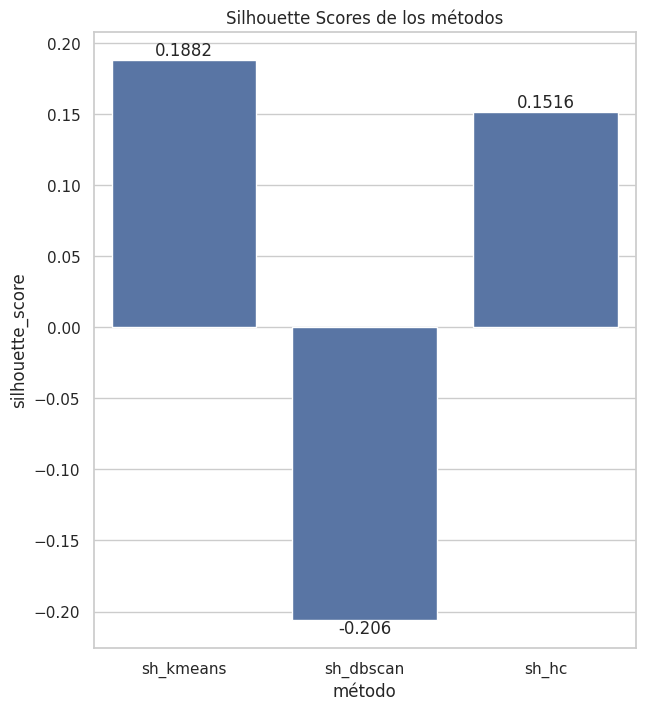

In [74]:
sil_score_df =pd.DataFrame({"sh_kmeans": [sil_score_kmeans],
                           "sh_dbscan": [sil_score_dbscan],
                           "sh_hc": [sil_score_hc]})
sil_score_df_T = sil_score_df.T
fig, ax = plt.subplots(figsize=(7, 8))
graf = sns.barplot(x=sil_score_df_T.index, y=sil_score_df_T.values.ravel(), ax=ax)
for values in ax.containers:
    ax.bar_label(values)
ax.set_title("Silhouette Scores de los métodos")
ax.set_xlabel("método")
ax.set_ylabel("silhouette_score")
plt.show()

### Interpretación de los resultados de las métricas:
- Los resultados muestran que ```K-Means``` obtuvo el valor más alto **(0.1882)**, seguido de ```AgglomerativeClustering``` **(0.1516)**, mientras que ```DBSCAN``` presentó un valor negativo **(-0.206)**.
- En contraste, ```K-Means``` y ```AgglomerativeClustering``` presentan coeficientes positivos, lo que indica una mejor separación entre clusters y mayor cohesión interna, siendo ```K-Means``` el método con mejor desempeño relativo.

## Añadiendo los clusters definidos al dataset utilizado

In [75]:
df_filt_copy = df_filtered.copy()
df_filt_copy.loc[:,"y_kmeans"] = y_kmeans
df_filt_copy.loc[:,"y_dbscan"] = y_dbscan
df_filt_copy.loc[:,"y_hc"] = y_hc

## Interpretación e identificación de los insights

In [76]:
df_mean = df_filt_copy.drop(["y_hc","y_dbscan"], axis=1).groupby("y_kmeans").mean().reset_index()
df_mean

,y_kmeans,Age,DistanceFromHome,Education,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,PerformanceRating,StandardHours,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole
0,0,31.552590,8.029827,2.659341,2.643642,1.277865,2.725275,3488.141287,3.144427,80.0,5.579278,3.296703,1.913658
1,1,47.799127,8.397380,3.048035,2.672489,4.043668,2.694323,15343.685590,3.152838,80.0,25.279476,14.681223,7.117904
2,2,38.465232,10.720199,3.129139,2.842715,2.142384,2.745033,6330.561258,3.163907,80.0,11.983444,8.013245,5.576159


In [77]:
print(df_filt_copy.drop(["y_dbscan","y_kmeans"], axis=1).groupby("y_hc").mean().std().sort_values(ascending=False))

MonthlyIncome         5846.475441
TotalWorkingYears        9.378764
Age                      7.392349
YearsAtCompany           5.080991
YearsInCurrentRole       2.755883
JobLevel                 1.317458
DistanceFromHome         0.728855
JobInvolvement           0.155752
Education                0.120811
PerformanceRating        0.099445
JobSatisfaction          0.057242
StandardHours            0.000000
dtype: float64


### Insigth observado:
Las variables con mayor desviación estándar entre las medias de los clusters son las más discriminativas, es decir, las que mejor separan los grupos:
- El clustering está capturando principalmente indicadores laborales "objetivas":
    - Salario ```MonthlyIncome```
    - Experiencia ```TotalWorkingYears```
    - Edad ```Age```
    - Antigüedad ```YearsAtCompany```

- Y está capturando mínimamente factores subjetivos como:
    - Satisfacción ```JobSatisfaction```
    - Compromiso ```JobInvolvement```

- Se podría inferir que el modelo segmenta a los empleados como:
    - Juniors vs Seniors
    - Salario bajo vs salario alto
    - Baja experiencia vs alta experiencia

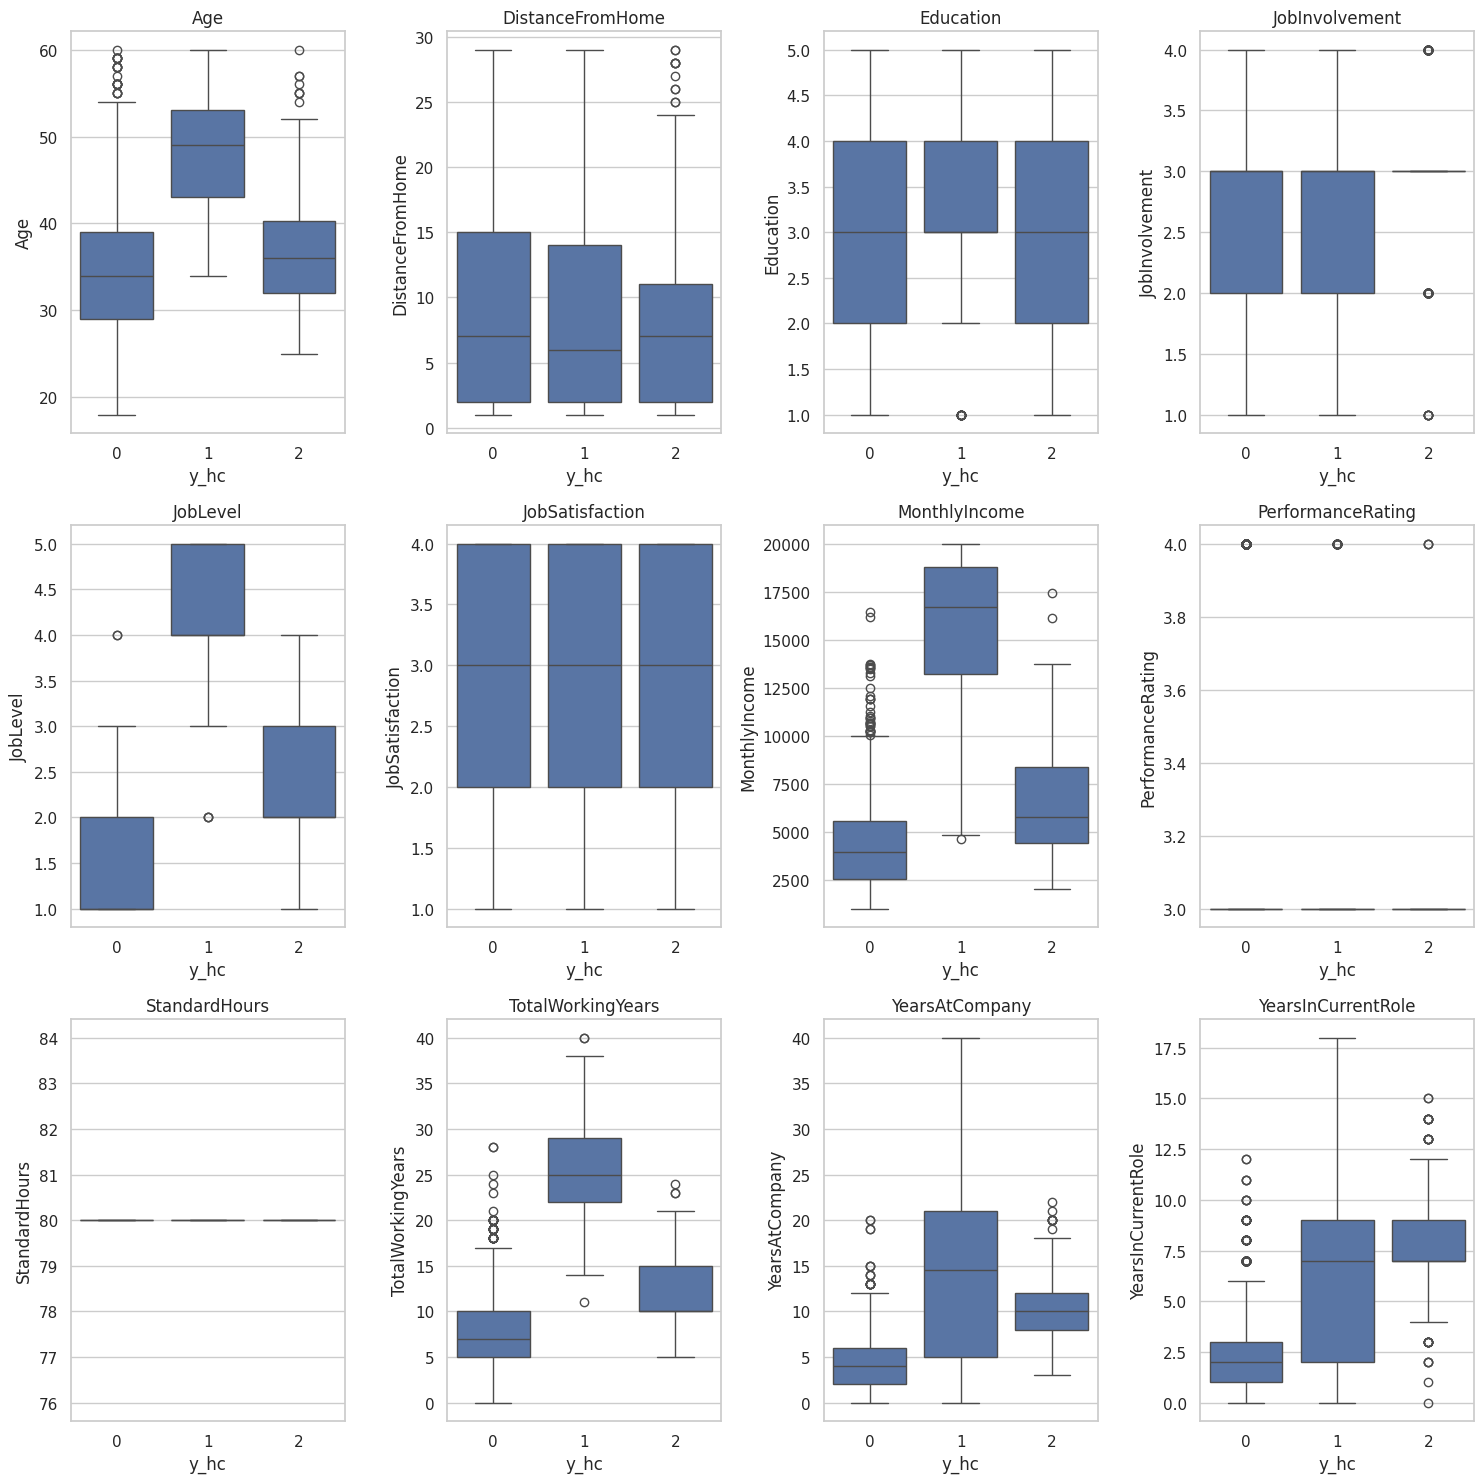

In [78]:
fig, ax = plt.subplots(3, 4, figsize=(15,15))
ax = ax.flatten()
for i, col in enumerate(df_filt_copy.drop(["y_dbscan","y_kmeans", "y_hc"], axis=1).columns):
    sns.boxplot(data=df_filt_copy, x="y_hc", y=col, ax=ax[i])
    ax[i].set_title(col)
plt.tight_layout()
plt.show()

## Conclusión final:
### Los resultados evidencian que las variables con mayor capacidad discriminativa entre los clusters son aquellas relacionadas con ingreso ```MonthlyIncome```, experiencia laboral ```TotalWorkingYears```, edad ```Age``` y antigüedad en la empresa ```YearsAtCompany```. En contraste, variables como satisfacción laboral ```JobSatisfaction```, ```JobInvolvement``` y educación ```Education``` presentan baja variabilidad entre clusters, lo que indica una menor influencia en la segmentación.